# Module 2 — Exploratory Data Analysis
### Real-time payment fraud detection for an e-commerce platform

This notebook explores the data in two passes:

- **Part A — before synthetic enrichment:** the base Kaggle *PaySim* transactions.
  We establish the class-imbalance baseline, the value at risk, and the structural
  facts (fraud only in certain transaction types, the drained-origin signature)
  that every later module leans on.
- **Part B — after synthetic enrichment:** the contextual/behavioural layer we
  generate in Module 1. Here the goal is **validation**: proving each risky
  signal raises the fraud rate *without* separating the classes (i.e. no leakage).

Throughout, we deliberately avoid *accuracy* and *ROC-AUC* framing. At ~0.13%
prevalence a "never fraud" model is 99.87% accurate and useless, so the language
we use is **prevalence, recall, precision, and value at risk** — the quantities
the Module-5 cost model actually optimises.

> **Assumptions:** both `data/raw/online_fraud_detection.csv` and
> `data/processed/transactions_enriched.parquet` already exist (run
> `setup_data.sh` and `scripts/generate_synthetic.py` first). This notebook only
> reads them.

## Setup

We bootstrap the repo root onto `sys.path` so `scripts.config` imports no matter
where the notebook is launched from, then pull every path/constant from the
central config (no hard-coded paths). Figures are **saved** to the `figures/`
folder *and* rendered inline, so they double as reusable report assets.

In [17]:
import sys, os
from pathlib import Path

# --- make scripts.config importable regardless of launch directory ---
def _find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "scripts" / "config.py").exists():
            return cand
    return p
ROOT_GUESS = _find_root(Path.cwd())
if str(ROOT_GUESS) not in sys.path:
    sys.path.insert(0, str(ROOT_GUESS))

from scripts.config import (RAW_DATA_PATH, ENRICHED_DATA_PATH, FIGURES, ROOT,
                            FRAUD_TYPES)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
FIGURES.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    "Save a figure to FIGURES/<name>.png (also shown inline by the notebook)."
    path = FIGURES / f"{name}.png"
    fig.savefig(path)
    print(f"saved -> {path.relative_to(ROOT)}")

def fraud_rate_by(df: pd.DataFrame, col: str) -> pd.DataFrame:
    "n, fraud count, and fraud rate (%) grouped by a column."
    g = df.groupby(col)["isFraud"].agg(n="count", fraud="sum", rate="mean")
    g["fraud_rate_%"] = (g["rate"] * 100).round(4)
    return g.drop(columns="rate")

print("Config loaded. ROOT =", ROOT)

Config loaded. ROOT = /Users/raven/Workspaces/business-analysis-hust


## Load the data

We read the base CSV (**Part A**) and the enriched parquet (**Part B**). If the
enriched file is missing the notebook still runs Part A and clearly flags Part B
as unavailable, rather than crashing.

In [18]:
assert RAW_DATA_PATH.exists(), f"Base CSV not found: {RAW_DATA_PATH} — run setup_data.sh"
base = pd.read_csv(RAW_DATA_PATH)
print(f"base: {len(base):,} rows x {base.shape[1]} cols")

HAS_ENRICHED = ENRICHED_DATA_PATH.exists()
if HAS_ENRICHED:
    enr = pd.read_parquet(ENRICHED_DATA_PATH)
    print(f"enriched: {len(enr):,} rows x {enr.shape[1]} cols")
else:
    enr = None
    print("enriched parquet NOT found — Part B will be skipped. "
          "Run scripts/generate_synthetic.py to enable it.")

base: 6,362,620 rows x 11 cols
enriched: 6,362,620 rows x 23 cols


# Part A — before synthetic enrichment (base PaySim)

## 1. Dataset overview

**Reasoning.** Before any modelling we need the shape of the raw data and a data-quality
baseline: dtypes, missing values, and duplicate rows. PaySim is a simulated log,
so it tends to be structurally clean — confirming that here tells us Module 3's
cleaning work will be about *outliers and balance quirks*, not imputation.

**What to look for.** Zero (or near-zero) missing cells and duplicates; the 11
expected base columns; `isFraud`/`isFlaggedFraud` as 0/1 integer labels.

**Business tie-in.** A clean base means the effort budget shifts toward feature
realism and the fraud-vs-friction trade-off, not data janitorial work.

In [19]:
overview = pd.DataFrame({
    "dtype": base.dtypes.astype(str),
    "n_missing": base.isnull().sum(),
    "n_unique": [base[c].nunique() for c in base.columns],
})
print(f"rows={len(base):,}  cols={base.shape[1]}  "
      f"duplicate_rows={base.duplicated().sum():,}  "
      f"total_missing_cells={int(base.isnull().sum().sum()):,}")
overview

rows=6,362,620  cols=11  duplicate_rows=0  total_missing_cells=0


,dtype,n_missing,n_unique
step,int64,0,743
type,str,0,5
amount,float64,0,5316900
nameOrig,str,0,6353307
oldbalanceOrg,float64,0,1845844
newbalanceOrig,float64,0,2682586
nameDest,str,0,2722362
oldbalanceDest,float64,0,3614697
newbalanceDest,float64,0,3555499
isFraud,int64,0,2


## 2. Class imbalance & value at risk

**Reasoning.** Fraud detection is an *imbalanced* problem, and the imbalance is the
whole reason accuracy is the wrong metric. We quantify prevalence (fraud ÷ total)
and, just as important, the **value at risk** — the share of total transaction
*value* that fraud represents. That number is what parameterises the cost of a
missed fraud (`C_fn ≈ amount`) in Module 5.

**What to look for.** Prevalence well under 1% (roughly 1 in ~775). And a value
share that is **higher** than the count share — meaning fraudulent transactions
are larger than average.

**Business tie-in.** Missing one fraud costs roughly the transaction amount plus
fees; blocking a legit order costs review labour + friction. Because fraud is a
small count but a larger slice of dollars, recall on high-value transactions is
where the money is.

fraud transactions : 8,213 of 6,362,620
prevalence         : 0.1291%  (~1 in 775)
a 'never fraud' model would be 99.8709% accurate — and useless
fraud value        : 12,056,415,428
total value        : 1,144,392,944,760
fraud share of $   : 1.0535%  (vs 0.1291% of count)
saved -> Module_08/figures/01_class_imbalance.png


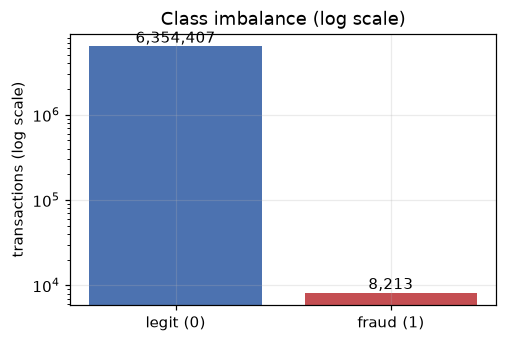

In [20]:
n = len(base); f = int(base.isFraud.sum()); prev = base.isFraud.mean()
fraud_val = base.loc[base.isFraud == 1, "amount"].sum()
tot_val = base["amount"].sum()
print(f"fraud transactions : {f:,} of {n:,}")
print(f"prevalence         : {prev*100:.4f}%  (~1 in {round(1/prev):,})")
print(f"a 'never fraud' model would be {100*(1-prev):.4f}% accurate — and useless")
print(f"fraud value        : {fraud_val:,.0f}")
print(f"total value        : {tot_val:,.0f}")
print(f"fraud share of $   : {fraud_val/tot_val*100:.4f}%  (vs {prev*100:.4f}% of count)")

fig, ax = plt.subplots(figsize=(5, 3.2))
counts = base.isFraud.value_counts().sort_index()
ax.bar(["legit (0)", "fraud (1)"], counts.values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log"); ax.set_ylabel("transactions (log scale)")
ax.set_title("Class imbalance (log scale)")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
save_fig(fig, "01_class_imbalance"); plt.show()

## 3. Fraud rate by transaction type

**Reasoning.** PaySim has a strong structural prior: fraud occurs **only** in
`TRANSFER` and `CASH_OUT`. Confirming this lets us restrict the modelling universe
to those two types, which also *reduces the effective imbalance*.

**What to look for.** Zero fraud in `PAYMENT`, `CASH_IN`, `DEBIT`; non-zero rates
only in the two fraud types. Prevalence *within* those two types should be several
times the global rate.

**Business tie-in.** Scoring effort (and analyst attention) should concentrate on
the two types where fraud is even possible — a free precision win before any model
is trained.

prevalence within ['TRANSFER', 'CASH_OUT']: 0.2965% (vs 0.1291% overall)
saved -> Module_08/figures/02_fraud_by_type.png


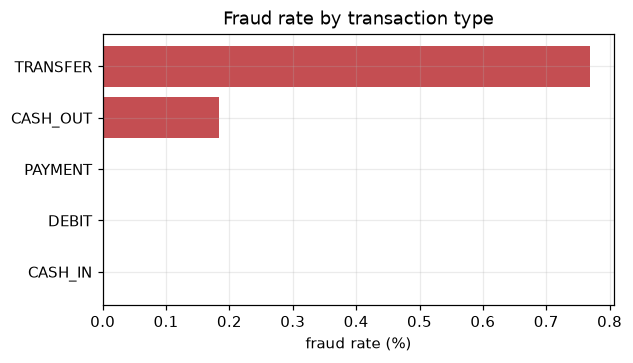

,n,fraud,fraud_rate_%
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237500,4116,0.1840
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


In [21]:
by_type = fraud_rate_by(base, "type").sort_values("fraud_rate_%", ascending=False)
within = base[base.type.isin(FRAUD_TYPES)]
print(f"prevalence within {FRAUD_TYPES}: {within.isFraud.mean()*100:.4f}% "
      f"(vs {base.isFraud.mean()*100:.4f}% overall)")

fig, ax = plt.subplots(figsize=(6, 3.2))
s = by_type.sort_values("fraud_rate_%")
ax.barh(s.index, s["fraud_rate_%"], color="#C44E52")
ax.set_xlabel("fraud rate (%)"); ax.set_title("Fraud rate by transaction type")
save_fig(fig, "02_fraud_by_type"); plt.show()
by_type

## 4. Transaction amount distribution

**Reasoning.** `amount` is heavily right-skewed, so we view it on a log scale and
compare the legit vs fraud distributions. Amount is central to the cost model, so
we need to understand where fraud sits in the distribution.

**What to look for.** A long right tail; the fraud distribution shifted toward
**larger** amounts relative to legit — consistent with account-draining behaviour.

**Business tie-in.** If fraud skews large, a fixed-dollar review threshold will
miss the expensive cases; the cost model's amount-weighting is what captures this.

,mean,50%,90%,99%,max
legit,178197.0,74684.7,364373.4,1586064.2,92445516.6
fraud,1467967.3,441423.4,4521723.5,10000000.0,10000000.0


saved -> Module_08/figures/03_amount_log.png


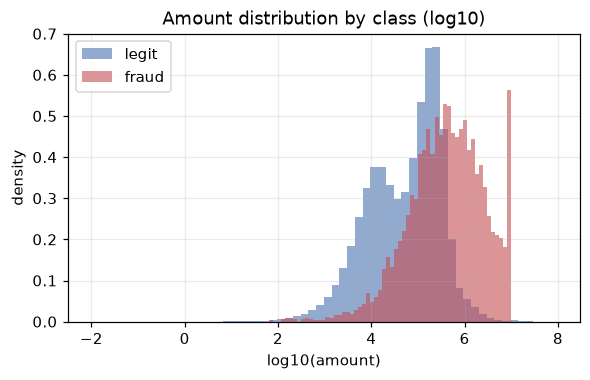

In [22]:
q = base.groupby("isFraud")["amount"].describe(percentiles=[.5, .9, .99])[
    ["mean", "50%", "90%", "99%", "max"]]
q.index = ["legit", "fraud"]
display(q.round(1))

d = base[base.amount > 0]
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(np.log10(d.loc[d.isFraud == 0, "amount"]), bins=60, alpha=.6,
        density=True, label="legit", color="#4C72B0")
ax.hist(np.log10(d.loc[d.isFraud == 1, "amount"]), bins=60, alpha=.6,
        density=True, label="fraud", color="#C44E52")
ax.set_xlabel("log10(amount)"); ax.set_ylabel("density")
ax.set_title("Amount distribution by class (log10)"); ax.legend()
save_fig(fig, "03_amount_log"); plt.show()

## 5. Balance mechanics — the drained-origin signature

**Reasoning.** In PaySim, fraudulent cash-outs typically **empty the origin
account**: `oldbalanceOrg ≈ amount` and `newbalanceOrig = 0`. We quantify this and
compute two reconciliation-error terms to see how often the ledger balances.

**What to look for.** A large fraction of fraud rows ending at a zero origin
balance; a non-trivial share of rows where `orig_err` ≠ 0 (a known PaySim
accounting quirk — a Module-3 cleaning item, not a bug).

**Business tie-in.** The drained-origin pattern is a powerful signal, *but* it is
partly mechanical/definitional. We flag it now so Module 4 treats it carefully and
doesn't let a near-tautology leak into the model.

In [23]:
d = base.copy()
d["orig_err"] = d.oldbalanceOrg - d.amount - d.newbalanceOrig
d["dest_err"] = d.oldbalanceDest + d.amount - d.newbalanceDest
drained = int(((d.isFraud == 1) & np.isclose(d.newbalanceOrig, 0)).sum())
nf = int(d.isFraud.sum())
print(f"fraud rows ending at zero origin balance: {drained:,} / {nf:,} "
      f"({drained/max(nf,1)*100:.1f}%)")
print(f"rows with non-zero orig_err (ledger quirk): {(~np.isclose(d.orig_err,0)).mean()*100:.1f}%")
tbl = d.groupby("isFraud")[["orig_err", "dest_err"]].mean()
tbl.index = ["legit", "fraud"]
tbl.round(1)

fraud rows ending at zero origin balance: 8,053 / 8,213 (98.1%)
rows with non-zero orig_err (ledger quirk): 80.6%


,orig_err,dest_err
legit,-201338.6,54692.2
fraud,-10692.3,732509.3


## 6. Destination type — merchant vs customer

**Reasoning.** Destination ids are prefixed `M…` (merchant) or `C…` (customer).
Merchants are never defrauded in PaySim, so the prefix is itself a signal.

**What to look for.** A fraud rate of exactly **zero** for merchant destinations
and all fraud concentrated on customer destinations.

**Business tie-in.** "Paying a known merchant" is a strong *negative* risk signal;
"transferring to another customer account" is where risk lives. A cheap rule-based
prior the model can build on.

In [24]:
d = base.assign(dest_type=np.where(base.nameDest.str.startswith("M"),
                                   "merchant (M)", "customer (C)"))
fraud_rate_by(d, "dest_type")

,n,fraud,fraud_rate_%
dest_type,,,
customer (C),4211125,8213,0.195
merchant (M),2151495,0,0.000


## 7. Time-of-day pattern

**Reasoning.** `hour_of_day = step % 24` is a **derived** field — nothing about it
is injected — so any pattern here is genuine PaySim structure. We check whether
fraud concentrates in particular hours.

**What to look for.** Elevated fraud rates in the low-activity night hours (0–5).
Because it's derived, this is *evidence about the real world*, not an artefact of
our generator.

**Business tie-in.** Time-of-day is a legitimate, cheap risk feature and a candidate
manual-review trigger, but only if the pattern is real — which is why we source it
from `step`, not from an injected distribution.

saved -> Module_08/figures/04_fraud_by_hour.png


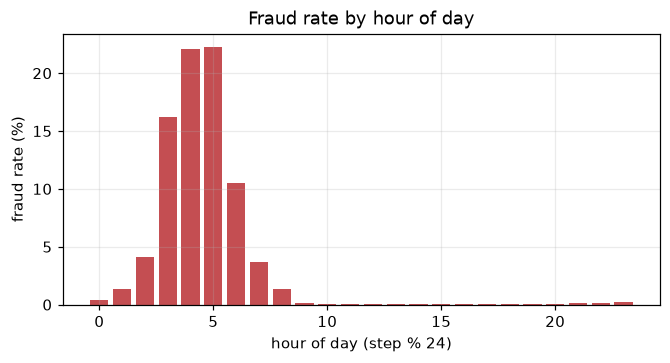

In [25]:
d = base.assign(hour=(base.step % 24))
g = fraud_rate_by(d, "hour")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(g.index, g["fraud_rate_%"], color="#C44E52")
ax.set_xlabel("hour of day (step % 24)"); ax.set_ylabel("fraud rate (%)")
ax.set_title("Fraud rate by hour of day")
save_fig(fig, "04_fraud_by_hour"); plt.show()

## 8. `isFlaggedFraud` — PaySim's built-in rule

**Reasoning.** PaySim ships a naive rule-based flag. We measure its recall to
decide whether it's worth keeping as a feature.

**What to look for.** It fires only a handful of times and catches a tiny fraction
of fraud — recall well under 1%.

**Business tie-in.** This is exactly the failure mode we're hired to fix: a
conservative hand-rule that almost never fires. We drop it and let a learned model
capture the trade-off instead.

In [26]:
flagged = int(base.isFlaggedFraud.sum())
caught = int(base.loc[base.isFlaggedFraud == 1, "isFraud"].sum())
tot = int(base.isFraud.sum())
print(f"isFlaggedFraud fires {flagged:,} times; catches {caught:,} of {tot:,} "
      f"frauds -> recall {caught/max(tot,1)*100:.2f}%  => drop it")

isFlaggedFraud fires 16 times; catches 16 of 8,213 frauds -> recall 0.19%  => drop it


## 9. Correlation among base numeric features

**Reasoning.** A quick linear-correlation view of the base numeric fields and the
label, to see where the base signal sits before we add context.

**What to look for.** Balance/amount fields carrying most of the (modest) linear
signal with `isFraud`; no single base feature strongly separating the classes.

**Business tie-in.** Confirms the base alone is a weak learner — which is the
motivation for the whole synthetic-context layer in Part B.

saved -> Module_08/figures/05_corr_base.png


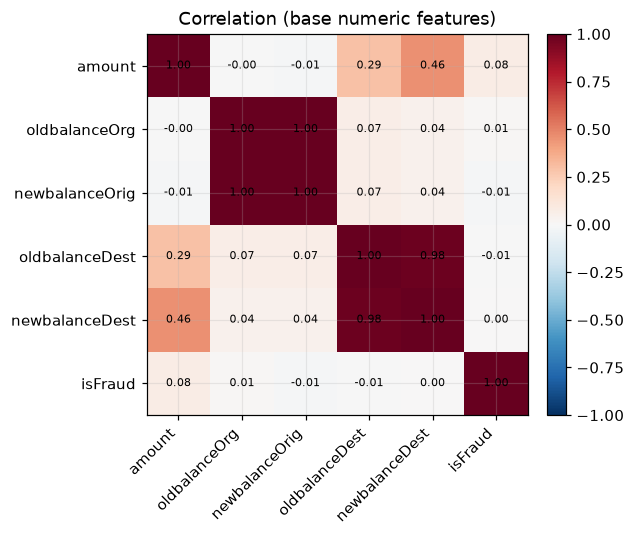

In [27]:
num = ["amount", "oldbalanceOrg", "newbalanceOrig",
       "oldbalanceDest", "newbalanceDest", "isFraud"]
corr = base[num].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=45, ha="right")
ax.set_yticks(range(len(num))); ax.set_yticklabels(num)
for i in range(len(num)):
    for j in range(len(num)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlation (base numeric features)")
save_fig(fig, "05_corr_base"); plt.show()

# Part B — after synthetic enrichment

Part B validates the Module-1 synthetic layer. The whole point of that layer is to
add **realistic, non-leaking** risk signals: each is drawn from an overlapping
distribution that is merely *more likely* under fraud, so no single feature
separates the classes and the fraud-vs-friction trade-off stays real. Everything
below is a check that this design actually held on the generated data.

*(If the enriched parquet wasn't found, the cells below will note that and skip.)*

## 10. Schema diff & merge integrity

**Reasoning.** Enrichment must **add** columns without altering the base rows.
We confirm the row count is unchanged, no nulls were introduced by the join, and
the account-level fields are genuinely constant per `nameOrig`.

**What to look for.** Identical row counts before/after; zero new nulls;
account-level fields stable per account. (Note: PaySim origin accounts are almost
all unique, so "stable per account" is barely exercised — a property of the base
data, and a reason to build velocity features on `nameDest` later.)

**Business tie-in.** If enrichment silently dropped or duplicated rows, every
downstream metric would be wrong. This is the data-integrity gate.

In [28]:
SYNTH_ACCOUNT = ["account_age_days", "home_billing_country", "home_device_id"]
SYNTH_TXN = ["device_id", "is_new_device", "browser_fingerprint",
             "shipping_billing_mismatch", "failed_payment_attempts",
             "ip_country", "ip_billing_distance_km"]
SYNTH_DERIVED = ["hour_of_day", "is_night"]
SYNTH_FLAGS = ["is_new_device", "shipping_billing_mismatch", "is_night"]
SYNTH_NUM = ["account_age_days", "failed_payment_attempts", "ip_billing_distance_km"]

if HAS_ENRICHED:
    added = [c for c in enr.columns if c not in base.columns]
    print(f"added {len(added)} columns: {added}")
    print(f"row count: base={len(base):,}  enriched={len(enr):,}  "
          f"-> {'preserved' if len(base)==len(enr) else 'CHANGED — investigate'}")
    print(f"new columns introduced zero nulls: {int(enr[added].isnull().sum().sum())==0}")
    stable = {c: int((enr.groupby('nameOrig')[c].nunique() > 1).sum())
              for c in SYNTH_ACCOUNT if c in enr.columns}
    print(f"accounts with a non-constant account-level field (want 0): {stable}")
else:
    print("enriched parquet not found — skipping Part B.")

added 12 columns: ['account_age_days', 'home_billing_country', 'home_device_id', 'device_id', 'is_new_device', 'browser_fingerprint', 'shipping_billing_mismatch', 'failed_payment_attempts', 'ip_country', 'ip_billing_distance_km', 'hour_of_day', 'is_night']
row count: base=6,362,620  enriched=6,362,620  -> preserved
new columns introduced zero nulls: True
accounts with a non-constant account-level field (want 0): {'account_age_days': 0, 'home_billing_country': 0, 'home_device_id': 0}


## 11. Anti-leakage lift tables

**Reasoning.** This is the central validation. For each binary risk flag we compute
the fraud rate when the flag is on vs off. The signal must **lift** the fraud rate
but must **not** separate the classes.

**What to look for.** Fraud rate meaningfully higher when the flag = 1 than = 0
(a lift), yet the "= 1" rate is still far from 100%. A flag that produced ~100%
fraud when on would be leakage and a generation bug. For the continuous signals we
plot fraud rate by decile — expect a gentle monotone-ish rise, never a clean step
to certainty.

**Business tie-in.** Overlap is what *creates* false positives and missed fraud —
i.e. the trade-off the platform actually manages. A leak-free signal is what makes
the later threshold/cost analysis meaningful rather than trivial.

In [29]:
if HAS_ENRICHED:
    rows = []
    for flag in SYNTH_FLAGS:
        r1 = enr.loc[enr[flag] == 1, "isFraud"].mean() * 100
        r0 = enr.loc[enr[flag] == 0, "isFraud"].mean() * 100
        rows.append({"signal": flag, "fraud_%_when_1": round(r1, 3),
                     "fraud_%_when_0": round(r0, 3),
                     "lift_x": round(r1 / r0, 1) if r0 else np.nan})
    display(pd.DataFrame(rows).set_index("signal"))
else:
    print("skipped — no enriched data.")

,fraud_%_when_1,fraud_%_when_0,lift_x
signal,,,
is_new_device,1.129,0.041,27.3
shipping_billing_mismatch,0.718,0.063,11.4
is_night,1.773,0.099,17.8


saved -> Module_08/figures/06_decile_account_age_days.png


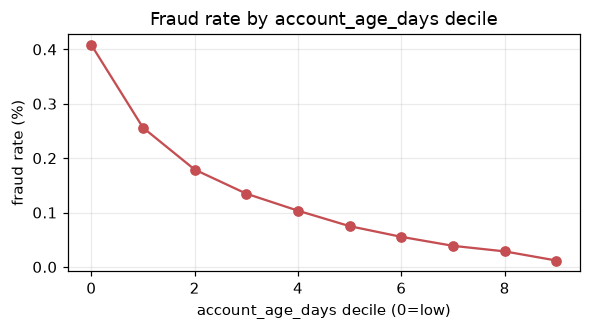

saved -> Module_08/figures/06_decile_failed_payment_attempts.png


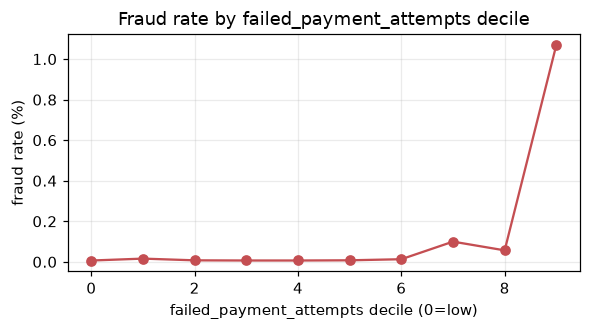

saved -> Module_08/figures/06_decile_ip_billing_distance_km.png


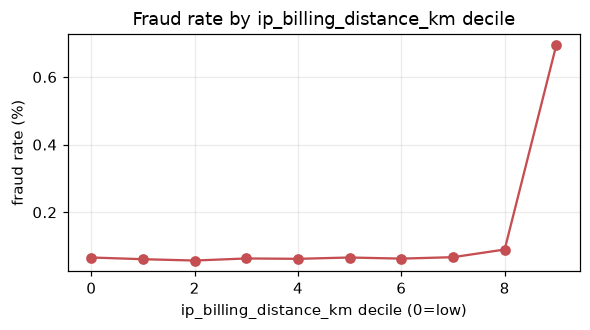

In [30]:
if HAS_ENRICHED:
    for col in SYNTH_NUM:
        dec = pd.qcut(enr[col].rank(method="first"), 10, labels=False)
        g = enr.groupby(dec)["isFraud"].mean() * 100
        fig, ax = plt.subplots(figsize=(6, 2.8))
        ax.plot(g.index, g.values, marker="o", color="#C44E52")
        ax.set_xlabel(f"{col} decile (0=low)"); ax.set_ylabel("fraud rate (%)")
        ax.set_title(f"Fraud rate by {col} decile")
        save_fig(fig, f"06_decile_{col}"); plt.show()
else:
    print("skipped — no enriched data.")

## 12. Correlation of synthetic features with `isFraud`

**Reasoning.** A one-glance leakage check: the Pearson correlation between each
synthetic feature and the label.

**What to look for.** All correlations **weak** (well away from ±1). No synthetic
field should be a near-deterministic function of fraud.

**Business tie-in.** Weak-but-real individual signals are exactly what force the
model to *combine* evidence — mirroring how real fraud teams reason across many
imperfect indicators rather than one silver bullet.

saved -> Module_08/figures/07_synth_corr.png


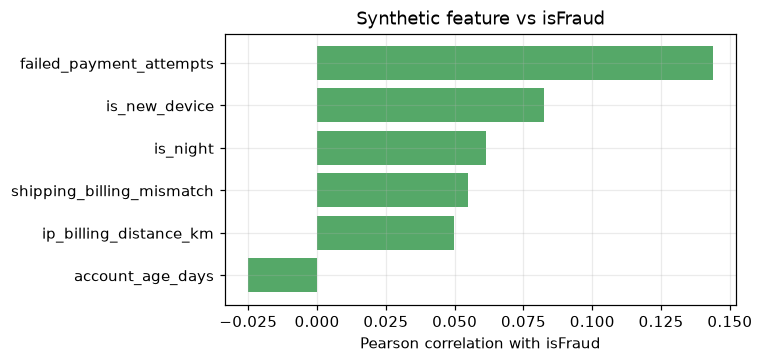

,corr_with_isFraud
account_age_days,-0.0251
ip_billing_distance_km,0.0496
shipping_billing_mismatch,0.0549
is_night,0.0614
is_new_device,0.0825
failed_payment_attempts,0.1438


In [31]:
if HAS_ENRICHED:
    cols = [c for c in (SYNTH_FLAGS + SYNTH_NUM) if c in enr.columns]
    c = enr[cols + ["isFraud"]].corr()["isFraud"].drop("isFraud").sort_values()
    fig, ax = plt.subplots(figsize=(6, 3.2))
    ax.barh(c.index, c.values, color="#55A868")
    ax.set_xlabel("Pearson correlation with isFraud")
    ax.set_title("Synthetic feature vs isFraud")
    save_fig(fig, "07_synth_corr"); plt.show()
    display(c.to_frame("corr_with_isFraud").round(4))
else:
    print("skipped — no enriched data.")

## 13. Multivariate lift — signals must be combined

**Reasoning.** We count how many risk flags are simultaneously active on a row and
look at the fraud rate as that count rises. This shows whether the signals *compose*.

**What to look for.** A steep climb in fraud rate as more flags stack — but note
that even all flags together should **not** guarantee fraud. That residual
uncertainty is the whole game.

**Business tie-in.** This is the risk-policy picture in miniature: one weak signal
→ monitor; several stacked → strong manual-review or auto-block candidate. It
directly informs the Module-8 policy recommendations.

,n,fraud,fraud_rate_%
0,5169983,807,0.016
1,1119887,3197,0.285
2,71109,3426,4.818
3,1641,783,47.715


saved -> Module_08/figures/08_multivariate_lift.png


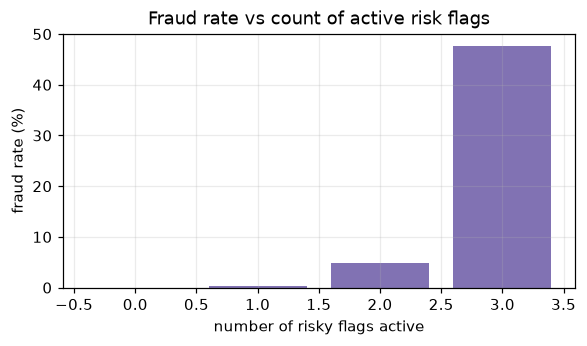

In [32]:
if HAS_ENRICHED:
    flags = [f for f in SYNTH_FLAGS if f in enr.columns]
    nflags = enr[flags].sum(axis=1)
    g = enr.groupby(nflags)["isFraud"].agg(n="count", fraud="sum", rate="mean")
    g["fraud_rate_%"] = (g["rate"] * 100).round(3); g = g.drop(columns="rate")
    display(g)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(g.index, g["fraud_rate_%"], color="#8172B3")
    ax.set_xlabel("number of risky flags active"); ax.set_ylabel("fraud rate (%)")
    ax.set_title("Fraud rate vs count of active risk flags")
    save_fig(fig, "08_multivariate_lift"); plt.show()
else:
    print("skipped — no enriched data.")

## 14. Data-quality & reproducibility notes (carried into Module 3)

These are findings surfaced by the EDA that the cleaning/feature modules should act on:

- **`browser_fingerprint` is not reproducible across runs.** It is built with
  Python's built-in `hash()`, which is salted per process by `PYTHONHASHSEED` and
  is **not** governed by the numpy seed in `config.py`. It is stable *within* a run
  (as documented), but the actual `fp_…` values change between runs/machines. If we
  need reproducibility, seed the mapping with numpy or set `PYTHONHASHSEED=0`. It
  does not affect modelling (we'd hash or drop the raw id anyway).
- **Balance-reconciliation quirks** (non-zero `orig_err`) are inherent to PaySim —
  a cleaning/documentation item, not a bug.
- **Origin accounts are near-unique**, so origin-level velocity features will be
  degenerate. Build velocity/aggregate features on `nameDest` (customer
  destinations recur), or accept that account-level context is effectively
  per-transaction here.
- **Modelling universe:** fraud only exists in `TRANSFER`/`CASH_OUT`, so the model
  can be trained on that subset, which also reduces the effective imbalance.